## Antonin VICTORION - 20231614 - BIA

# LAB 1: Multi-Class Classification using scikit-learn MLP Classifier on Forest Cover Type Dataset

In [4]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


Load the Data

In [2]:
from ucimlrepo import fetch_ucirepo 

In [4]:
from sklearn.datasets import fetch_covtype

covtype = fetch_covtype(as_frame=True)
X = covtype.data
y = covtype.target

print(X.shape, y.shape)
print(y.name, sorted(y.unique()))

(581012, 54) (581012,)
Cover_Type [1, 2, 3, 4, 5, 6, 7]


Data preprocessing

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

y = y.squeeze()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train = pd.get_dummies(y_train, dtype=int).values
y_test = pd.get_dummies(y_test, dtype=int).values



### Build the MLP Classifier using scikit-learn

Import the MLP Classifier

In [7]:
from sklearn.neural_network import MLPClassifier

Define the MLP model with two hidden layers (128, 64 neurons)

In [8]:
mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu',
 solver = 'adam', max_iter=200, random_state=42)

Train the MLP model

In [9]:
mlp.fit(X_train,y_train.argmax(axis=1)) #Using integer-encoded labels for training

c:\Tools\Anaconda\envs\mlp-lab\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128, 64), random_state=42)

In [10]:
# Make predictions
y_pred_mlp=mlp.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix

# Print classification report
print('Classification Report (MLP Classifier):\n',
        classification_report(y_test.argmax(axis=1), y_pred_mlp))

Classification Report (MLP Classifier):
               precision    recall  f1-score   support

           0       0.92      0.92      0.92     42368
           1       0.93      0.94      0.94     56661
           2       0.91      0.92      0.92      7151
           3       0.80      0.83      0.82       549
           4       0.84      0.75      0.80      1899
           5       0.82      0.88      0.85      3473
           6       0.95      0.93      0.94      4102

    accuracy                           0.92    116203
   macro avg       0.88      0.88      0.88    116203
weighted avg       0.92      0.92      0.92    116203



In [12]:
# confusion matrix
cm_mlp = confusion_matrix(y_test.argmax(axis=1), y_pred_mlp)
print('Confusion Matrix (MLP Classifier):\n', cm_mlp)

Confusion Matrix (MLP Classifier):
 [[38902  3255     3     0    22     8   178]
 [ 2882 53076   189     1   235   244    34]
 [    1    85  6607    81     6   371     0]
 [    0     0    61   454     0    34     0]
 [   56   352    43     0  1429    19     0]
 [    3    36   347    28     2  3057     0]
 [  242    34     0     0     1     0  3825]]


Visualize the Confusion Matrix

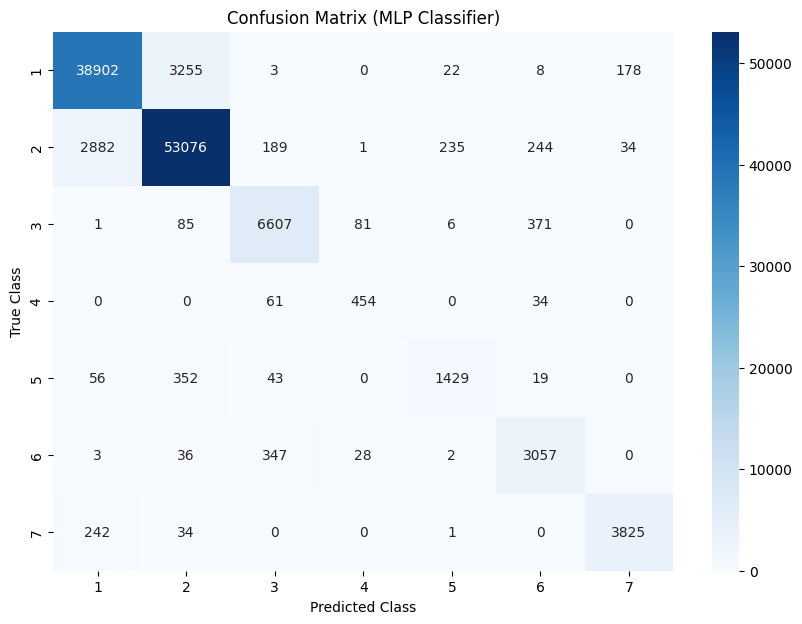

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm_mlp,	annot=True,	fmt='d',	cmap='Blues',	xticklabels=np.arange(1,	8),	
yticklabels=np.arange(1,	8))	
plt.title('Confusion Matrix (MLP Classifier)')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

**Baseline MLP results.** The (128, 64) ReLU/Adam model reaches **92% accuracy** (macro F1 = 0.88, weighted F1 = 0.92). Performance is excellent on the two majority classes (F1 ≈ 0.92–0.94) and on the smaller classes, but it is weaker on the rarest ones: class 3 (support = 549, F1 = 0.82) and class 4 (recall = 0.75, F1 = 0.80). The confusion matrix shows that most errors come from the confusion between the two dominant classes (≈ 3,255 and 2,882 misclassifications between classes 1 and 2), which are probably ecologically similar. Note that the classification report uses labels 0–6 while the heatmap axes use 1–7 (same classes, shifted index). Training stopped at the 200-iteration limit (`ConvergenceWarning`), so the model had not fully converged.

Experiment with Hyperparameters

In [17]:
# Define a new MLP model with different hyperparameters

mlp_tuned = MLPClassifier(hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
max_iter = 200, alpha=0.001, learning_rate_init=0.001, random_state= 42, early_stopping=True )

# Train the tuned model
mlp_tuned.fit(X_train, y_train.argmax(axis=1))

# Predict and evaluate the tuned model
y_pred_tuned = mlp_tuned.predict(X_test)

print('Classification	Report	(Tuned	MLP	Classifier):\n',	
classification_report(y_test.argmax(axis=1),	y_pred_tuned))	

Classification	Report	(Tuned	MLP	Classifier):
               precision    recall  f1-score   support

           0       0.92      0.90      0.91     42368
           1       0.92      0.93      0.93     56661
           2       0.88      0.92      0.90      7151
           3       0.83      0.78      0.81       549
           4       0.77      0.76      0.77      1899
           5       0.85      0.77      0.81      3473
           6       0.91      0.92      0.92      4102

    accuracy                           0.91    116203
   macro avg       0.87      0.86      0.86    116203
weighted avg       0.91      0.91      0.91    116203



**Tuned MLP results.** With `alpha=0.001`, `learning_rate_init=0.001` and `early_stopping=True`, accuracy is **91%** (macro F1 = 0.86), i.e. about 1 point below the baseline. This is not a pure comparison of `alpha`/learning rate: early stopping holds out 10% of the training set as a validation set and stops training as soon as the validation score stops improving, so the tuned model is trained on less data and for fewer epochs. The slightly lower scores (notably on minority classes 4 and 5) suggest that, on this large dataset (≈ 464k training samples), the baseline benefits from longer training rather than from additional regularization.

Learning Curves

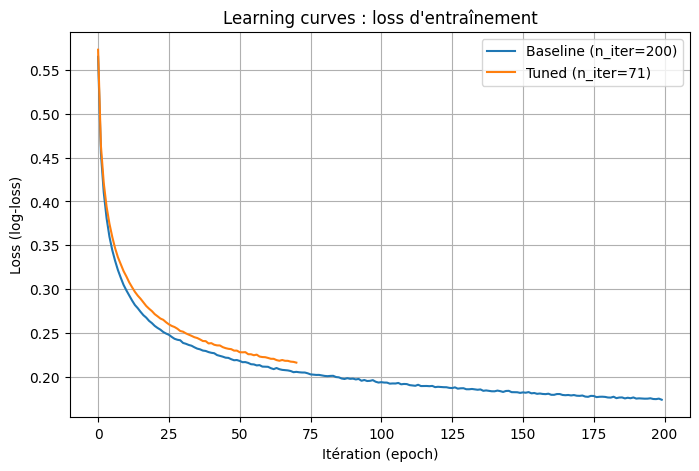

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, label=f'Baseline (n_iter={mlp.n_iter_})')
plt.plot(mlp_tuned.loss_curve_, label=f'Tuned (n_iter={mlp_tuned.n_iter_})')
plt.xlabel('Itération (epoch)')
plt.ylabel('Loss (log-loss)')
plt.title('Learning curves : loss d\'entraînement')
plt.legend()
plt.grid(True)
plt.show()

**Learning curves.** The baseline loss keeps decreasing until the 200-iteration limit, confirming that it had not fully converged and that it could still improve with more iterations. The tuned model stops much earlier thanks to early stopping, and its final training loss is higher. Neither curve shows divergence or instability, so the learning rate of 0.001 is appropriate for Adam on this dataset.

Cross-Validation

In [24]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation  
cv_scores = cross_val_score(mlp_tuned, X_train, y_train.argmax(axis=1),cv=5, n_jobs=5, verbose=1)
print("Cross-Validation	Accuracy:	%.2f%%"	%	(cv_scores.mean()*100))	


[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  5.5min remaining:  8.3min
[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  8.1min finished


Cross-Validation	Accuracy:	91.06%


**Cross-validation.** The 5-fold cross-validated accuracy of the tuned MLP is **91.06%**, consistent with the test accuracy (91%). This shows that the result does not depend on a particular train/test split and that the model is not overfitting. The cost is high: cross-validation took about 8 minutes (5 folds in parallel), which illustrates the computational cost of MLPs.

### Analysis and Discussion

**1. Performance comparison.** The MLP reaches 92% accuracy (baseline) and 91% (tuned). Compared with the previous models: Logistic Regression = [ ... ]% and k-NN = [ ... ]%. [ Explain here which model is best and why. ] The Forest Cover Type problem is strongly non-linear (interactions between elevation, soil type and wilderness area), which a linear model such as Logistic Regression cannot capture, whereas an MLP learns non-linear decision boundaries through its hidden layers.

**2. Hyperparameters.** Increasing `alpha` and enabling early stopping slightly reduced accuracy (92% → 91%), because they limit the effective capacity/training time of a model that is not overfitting. [ If you tested other architectures, learning rates or `solver='sgd'`, report them here. ]

**3. Training time.** The MLP is much more expensive than Logistic Regression or k-NN: [ baseline fit time ] for the baseline, and cross-validation took about 8 minutes. The trade-off is therefore: [ +x points of accuracy ] against [ y times longer training ]. Early stopping reduces this cost at a small accuracy loss.

# LAB 2: Studying Universal Approximation in Neural Networks

### Step 1: Data Generation

In [26]:
# Function definition

def f(x):
    if -1<x<1:
        return np.sin(np.pi*x)
    else:
        return 0

# Generate data

np.random.seed(42)
X2_train = np.random.uniform(-2,2,1000)
y2_train = np.array([f(x) + np.random.normal(0,0.2) for x in X2_train])

# For the test set

X2_test = np.random.uniform(-2,2,200)
y2_test = np.array([f(x)+np.random.normal(0,0.2) for x in X2_test])

The target function is f(x) = sin(πx) on ]−1, 1[ and 0 on [−2, −1] ∪ [1, 2], with Gaussian noise of standard deviation 0.2. Since the noise variance is 0.2² = **0.04**, this is the irreducible error: no model can reach a test MSE below ≈ 0.04. The function is continuous at x = ±1 (sin(±π) = 0), but its slope changes abruptly there, which is what makes it hard to approximate with few neurons.

### Step 2: MLP Implementation with TensorFlow

In [27]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Model definition

model = models.Sequential()
model.add(layers.Dense(10, activation='tanh', input_shape=(1,))) # Hidden layer with tanh
model.add(layers.Dense(1)) # Output layer wth no activation function  

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model

model.fit(X2_train, y2_train, epochs=100, batch_size=32, validation_data=(X2_test, y2_test))




Epoch 1/100

32/32 [==============================] - 1s 9ms/step - loss: 0.2821 - val_loss: 0.3323
Epoch 2/100
32/32 [==============================] - 0s 5ms/step - loss: 0.2734 - val_loss: 0.3239
Epoch 3/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2657 - val_loss: 0.3142
Epoch 4/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2581 - val_loss: 0.3061
Epoch 5/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2512 - val_loss: 0.2991
Epoch 6/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2446 - val_loss: 0.2897
Epoch 7/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2384 - val_loss: 0.2823
Epoch 8/100
32/32 [==============================] - 0s 3ms/step - loss: 0.2316 - val_loss: 0.2745
Epoch 9/100
32/32 [==============================] - 0s 4ms/step - loss: 0.2255 - val_loss: 0.2671
Epoch 10/100
32/32 [==============================] - 0s 5ms/step - loss: 0.2197 - val_loss: 0.2592
Epoch 

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                20        
                                                                 
 dense_1 (Dense)             (None, 1)                 11        
                                                                 
Total params: 31 (124.00 Byte)
Trainable params: 31 (124.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Number of neurons variation

In [29]:
def build_model(n):
    model=models.Sequential()
    model.add(layers.Input(shape=(1,)))
    model.add(layers.Dense(n, activation='tanh'))
    model.add(layers.Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

In [34]:
def f_vec(x):
    return np.where((x>-1) & (x<1), np.sin(np.pi*x), 0)

In [30]:
neurons_list = [1, 3, 5, 7, 10, 15, 20]
EPOCHS = 100
x_grid = np.linspace(-2, 2, 400)

results = []
preds ={}

for n in neurons_list:
    model = build_model(n)
    model.fit(X2_train, y2_train, epochs=EPOCHS, batch_size=32,validation_data=(X2_test, y2_test), verbose=0)
    
    mse_train = model.evaluate(X2_train, y2_train, verbose=0)
    mse_test = model.evaluate(X2_test, y2_test, verbose=0)

    preds[n] = model.predict(x_grid, verbose=0).flatten()
    results.append((n, mse_train, mse_test))
    
    
    

In [31]:
#MSE results
print(f"{'n':>4} | {'MSE Train':>10} | {'MSE Test':>10}")
for n, mse_train, mse_test in results:
    print(f"{n:>4} | {mse_train:>10.4f} | {mse_test:>10.4f}")

   n |  MSE Train |   MSE Test
   1 |     0.2829 |     0.3440
   3 |     0.0861 |     0.0918
   5 |     0.0863 |     0.0965
   7 |     0.0734 |     0.0788
  10 |     0.0833 |     0.0890
  15 |     0.0846 |     0.0905
  20 |     0.0742 |     0.0803


**Effect of the number of hidden neurons (100 epochs).**

| Neurons | MSE train | MSE test |
|---|---|---|
| 1 | 0.2829 | 0.3440 |
| 3 | 0.0861 | 0.0918 |
| 5 | 0.0863 | 0.0965 |
| 7 | 0.0734 | 0.0788 |
| 10 | 0.0833 | 0.0890 |
| 15 | 0.0846 | 0.0905 |
| 20 | 0.0742 | 0.0803 |

With **1 neuron**, the model is a single tanh unit followed by a linear output: it can only produce one monotonic S-shaped curve, so it cannot reproduce the sine arch nor the flat zero regions (MSE ≈ 0.28–0.34, far from the 0.04 floor). From **3 neurons** the error drops sharply, since the network can combine several tanh units to build the bump shape of sin(πx) inside ]−1, 1[ and a flat output outside, which is the idea of sparse approximation: very few neurons are sufficient to approximate the function. Beyond 3–7 neurons the MSE no longer decreases monotonically with capacity (e.g. 10 and 15 neurons are worse than 7). This is not a sign of overfitting, as train and test MSE move together, but of **incomplete convergence**: with 100 epochs of Adam the training loss was still decreasing, and the final result depends on the random initialization.

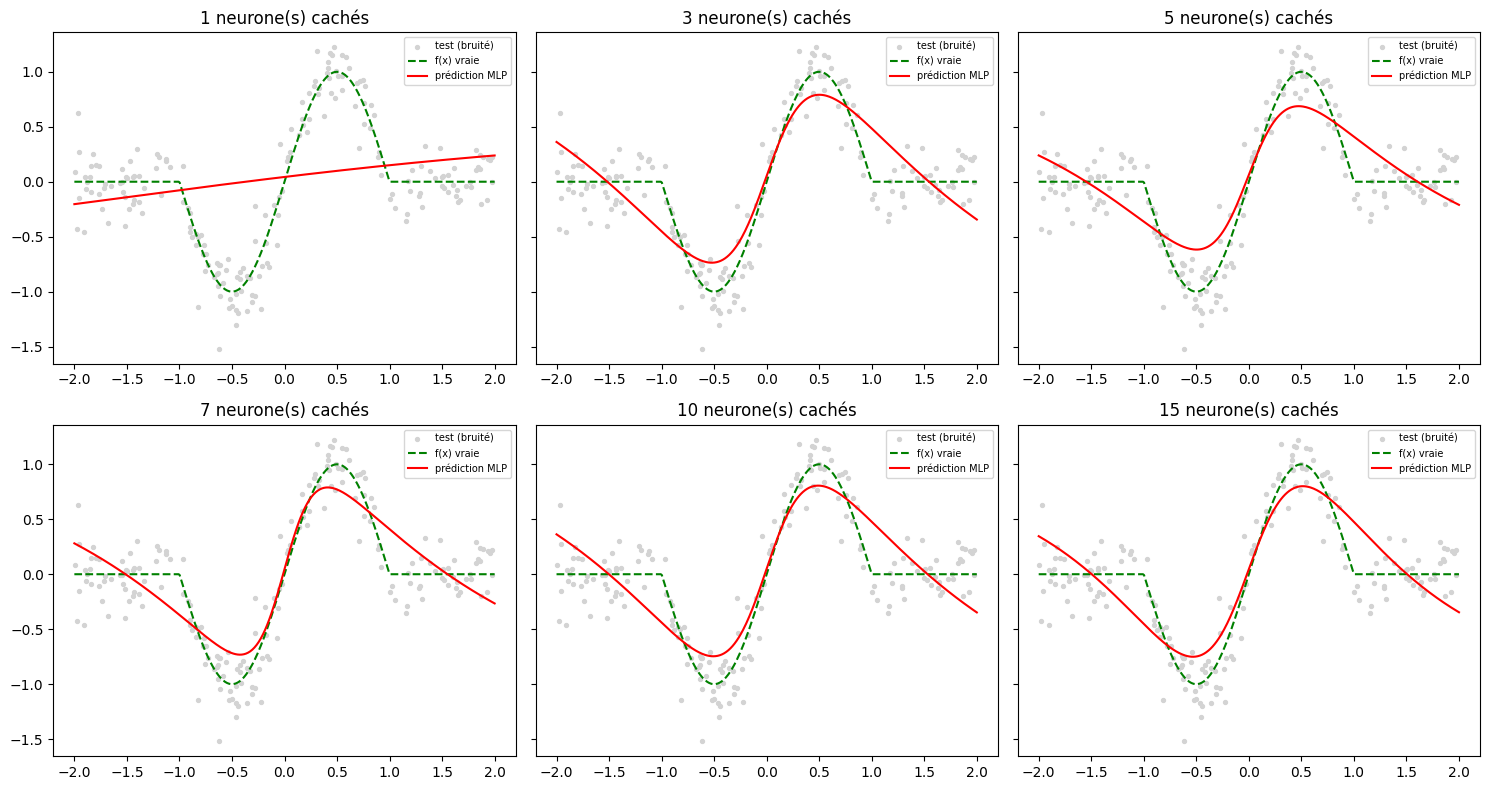

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, n in zip(axes.flatten(), neurons_list):
    ax.scatter(X2_test, y2_test, s=8, color='lightgray', label='test (bruité)')
    ax.plot(x_grid, f_vec(x_grid), 'g--', label='f(x) vraie')
    ax.plot(x_grid, preds[n], 'r', label='prédiction MLP')
    ax.set_title(f'{n} neurone(s) cachés')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig('lab2_curves.png', dpi=120)
plt.show()

   n |  MSE train |   MSE test
--------------------------------
   3 |     0.0520 |     0.0536
  10 |     0.0438 |     0.0460
  50 |     0.0446 |     0.0460


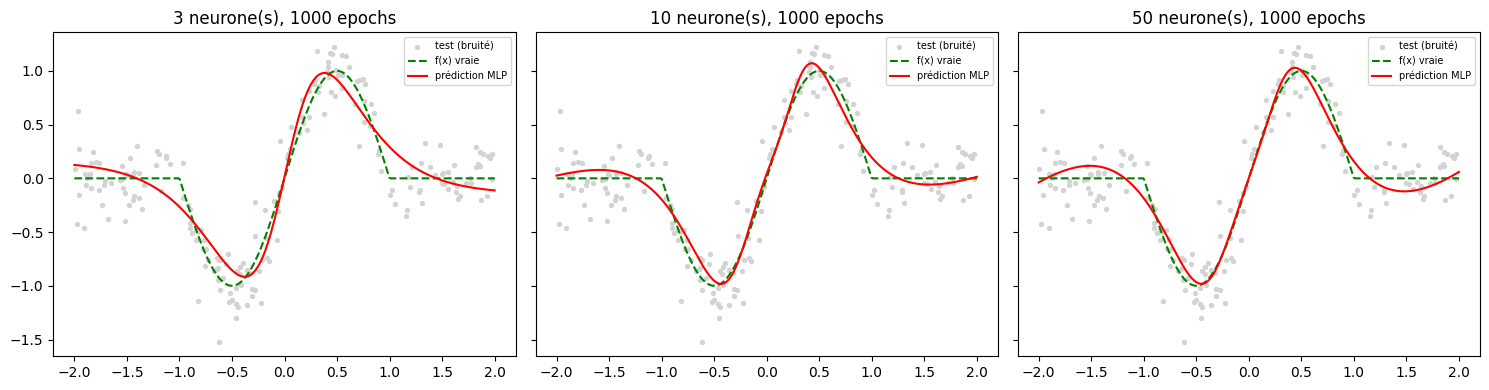

In [38]:
EPOCHS_LONG = 1000
neurons_long = [3, 10, 50]
preds_long = {}
results_long = []

for n in neurons_long:
    model = build_model(n)
    model.fit(X2_train, y2_train, epochs=EPOCHS_LONG, batch_size=32,
              validation_data=(X2_test, y2_test), verbose=0)
    mse_train = model.evaluate(X2_train, y2_train, verbose=0)
    mse_test = model.evaluate(X2_test, y2_test, verbose=0)
    preds_long[n] = model.predict(x_grid, verbose=0).flatten()
    results_long.append((n, mse_train, mse_test))

print(f"{'n':>4} | {'MSE train':>10} | {'MSE test':>10}")
print("-" * 32)
for n, tr, te in results_long:
    print(f"{n:>4} | {tr:>10.4f} | {te:>10.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, n in zip(axes, neurons_long):
    ax.scatter(X2_test, y2_test, s=8, color='lightgray', label='test (bruité)')
    ax.plot(x_grid, f_vec(x_grid), 'g--', label='f(x) vraie')
    ax.plot(x_grid, preds_long[n], 'r', label='prédiction MLP')
    ax.set_title(f'{n} neurone(s), {EPOCHS_LONG} epochs')
    ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

**Longer training (1000 epochs).**

| Neurons | MSE train | MSE test |
|---|---|---|
| 3 | 0.0520 | 0.0536 |
| 10 | 0.0438 | 0.0460 |
| 50 | 0.0446 | 0.0460 |

With enough epochs, the results become consistent: more neurons give a lower error, and 10 and 50 neurons both reach a test MSE of **0.046**, very close to the noise floor (0.04). Going from 10 to 50 neurons brings no gain, so around 10 neurons are enough to approximate this function. Train and test MSE remain close (no overfitting), and the red curves follow the true function f(x), including the kinks at x = ±1, although they smooth the sharp transitions slightly.

# Conclusion

- **Lab 1:** the MLP reaches 91–92% accuracy on Forest Cover Type, confirming its ability to learn non-linear patterns, at the price of a significantly higher training time. Early stopping and extra regularization did not help here.
- **Lab 2:** a one-hidden-layer MLP approximates the piecewise function well (universal approximation), and the required number of neurons is small (≈ 3 for a rough fit, ≈ 10 to reach the noise floor). Capacity matters, but so does training length: an under-trained network can look worse than a smaller, fully converged one.